# Audio Steganography

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ziadelh/audio-steganography/blob/main/audio_steganography.ipynb)

Two experiments in hiding information inside sound:

1. **Finding a hidden code.** Four recordings are supplied and one of them hides a four-digit code above the range of normal hearing. The notebook finds the suspicious file from its high-frequency energy, recovers the code as audible speech and transcribes it.
2. **Hiding a message of my own.** A text message is hidden in the least significant bits of a recording at pseudo-random positions, then extracted again with the same key.

Everything runs top to bottom. On Colab the first cell downloads the repository (the audio is in `data/`) and a small offline speech model.

## Setup

In [1]:
import os, subprocess, sys, urllib.request, zipfile

REPO_URL = "https://github.com/ziadelh/audio-steganography.git"

# On Colab the repository is not on disk yet, so fetch it (the audio files are in data/)
if not os.path.exists("data/Ex3_sound1.wav"):
    if not os.path.exists("audio-steganography"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir("audio-steganography")

# install the libraries that are missing (Colab already has numpy, scipy and matplotlib)
for module, package in [("vosk", "vosk"), ("soundfile", "soundfile")]:
    try:
        __import__(module)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# download the small English speech model (about 40 MB) the first time
MODEL_DIR = "vosk-model-small-en-us-0.15"
if not os.path.isdir(MODEL_DIR):
    urllib.request.urlretrieve(f"https://alphacephei.com/vosk/models/{MODEL_DIR}.zip", "vosk-model.zip")
    zipfile.ZipFile("vosk-model.zip").extractall(".")
    os.remove("vosk-model.zip")

os.makedirs("output", exist_ok=True)
print("Ready.")

Ready.


In [2]:
import json
import os
import random
import warnings
import wave

import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wav
import soundfile as sf
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt, hilbert
from vosk import KaldiRecognizer, Model, SetLogLevel

SetLogLevel(-1)   # keep the speech model's log messages out of the notebook
warnings.filterwarnings("ignore", category=wav.WavFileWarning)   # the supplied WAVs carry an extra metadata chunk

## Part 1: Finding the hidden code

The code was amplitude-modulated onto a high-frequency carrier (about 19 kHz, above what most people can hear) and mixed into one of the four recordings. A band-pass filter that keeps only 15-20 kHz isolates that range. The recording with by far the most energy there is the suspicious one.

In [3]:
files = [f"data/Ex3_sound{i}.wav" for i in range(1, 5)]

def butter_bandpass(lowcut, highcut, fs, order=6):
    nyq = 0.5 * fs
    return butter(order, [lowcut / nyq, highcut / nyq], btype='band')

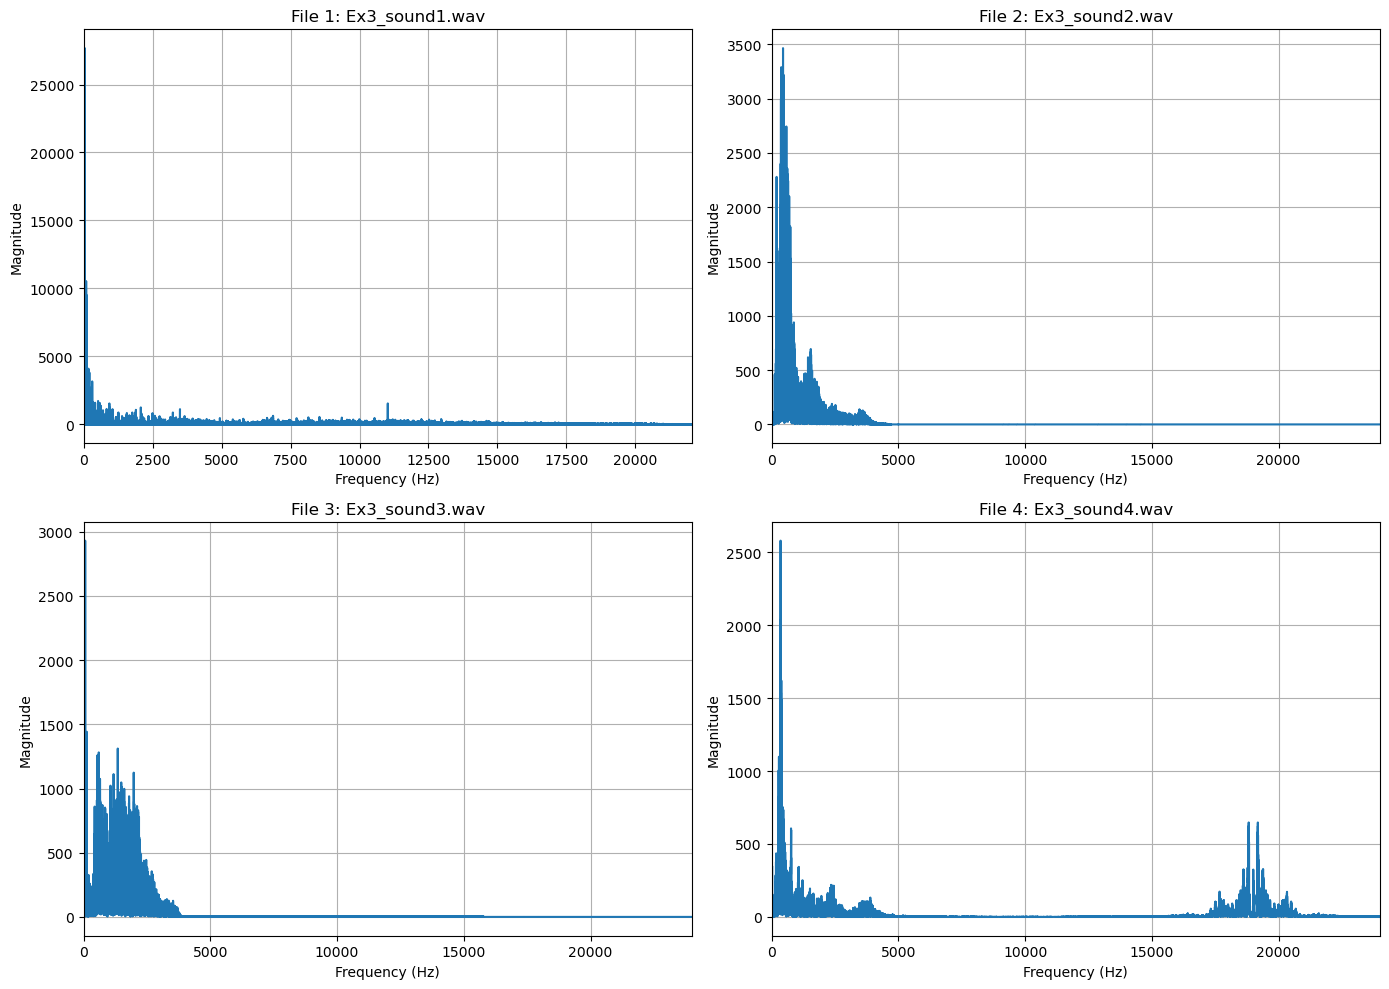

In [4]:
energy_scores = []
plt.figure(figsize=(14, 10))

for idx, file in enumerate(files):
    sr, data = wav.read(file)
    if data.ndim > 1:
        data = data.mean(axis=1)
    data = data / np.max(np.abs(data))

    b, a = butter_bandpass(15000, 20000, sr)
    filtered = filtfilt(b, a, data)
    energy = np.sum(filtered**2)
    energy_scores.append(energy)

    N = len(data)
    yf = fft(data)
    xf = fftfreq(N, 1/sr)

    plt.subplot(2, 2, idx+1)
    plt.plot(xf[:N//2], np.abs(yf[:N//2]))
    plt.title(f"File {idx+1}: {os.path.basename(file)}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, sr/2)
    plt.grid(True)

plt.tight_layout()
plt.show()

#### Energy between 15 and 20 kHz

In [5]:
for file, energy in zip(files, energy_scores):
    print(f"{os.path.basename(file)}: {energy:10.4f}")

suspicious_index = int(np.argmax(energy_scores))
suspicious_file = files[suspicious_index]
print(f"\nSuspicious file detected: {suspicious_file}")

others = [e for i, e in enumerate(energy_scores) if i != suspicious_index]
print(f"It has {energy_scores[suspicious_index] / max(others):.0f} times the energy in that band of the next highest file.")

Ex3_sound1.wav:    43.2373
Ex3_sound2.wav:     0.0001
Ex3_sound3.wav:     0.0249
Ex3_sound4.wav:   780.8260

Suspicious file detected: data/Ex3_sound4.wav
It has 18 times the energy in that band of the next highest file.


#### Recovering the code

Taking the envelope of the band-passed signal (the magnitude of its analytic signal, from the Hilbert transform) demodulates the amplitude-modulated carrier and brings the hidden speech back to the audible range.

In [6]:
sr, data = wav.read(suspicious_file)
if data.ndim > 1:
    data = data.mean(axis=1)
data = data / np.max(np.abs(data))

b, a = butter_bandpass(15000, 20000, sr)
filtered_data = filtfilt(b, a, data)
analytic_signal = hilbert(filtered_data)
amplitude_envelope = np.abs(analytic_signal)
amplitude_envelope = amplitude_envelope / np.max(amplitude_envelope)
recovered_audio = (amplitude_envelope * 0.9).astype(np.float32)

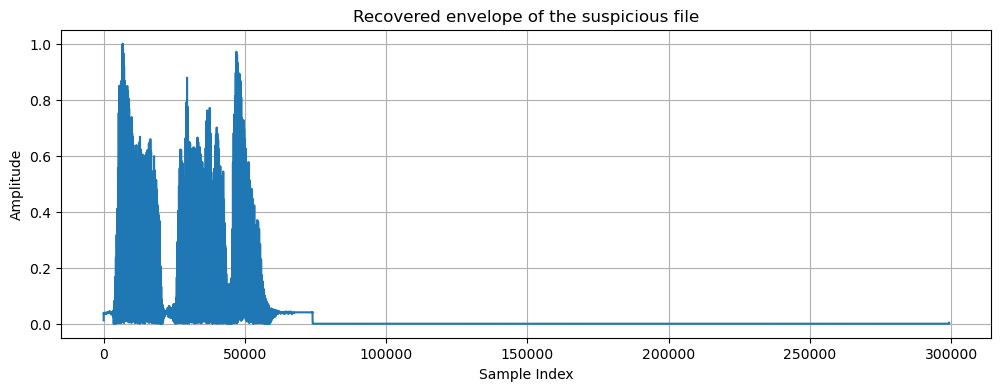

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(amplitude_envelope)
plt.title("Recovered envelope of the suspicious file")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [8]:
# Save the decoded audio so it can be played
sf.write("output/recovered_message.wav", recovered_audio, sr)
print("Recovered audio saved as output/recovered_message.wav")

Recovered audio saved as output/recovered_message.wav


The recovered speech is transcribed offline with Vosk, so no audio leaves the machine.

In [9]:
model = Model(MODEL_DIR)
wf = wave.open("output/recovered_message.wav", "rb")
rec = KaldiRecognizer(model, wf.getframerate())

results = []
while True:
    chunk = wf.readframes(4000)
    if len(chunk) == 0:
        break
    if rec.AcceptWaveform(chunk):
        results.append(json.loads(rec.Result()).get("text", ""))
results.append(json.loads(rec.FinalResult()).get("text", ""))   # words still buffered at the end of the audio

final_text = " ".join(t for t in results if t)
print("Recovered Secret Code:", final_text)

Recovered Secret Code: one eight nine one


## Part 2: Hiding a message in the least significant bits

The message is turned into bits (8 per character). Every pair of bits replaces the **two least significant bits** of one 16-bit sample, and the samples are chosen **at random positions** from a seeded generator instead of one after another. That changes each chosen sample by at most 3 out of 32,768, which cannot be heard, and the scattered positions make the message hard to find without the key. To read it back you need the seed and the message length.

In [10]:
# Convert message to binary
def text_to_bits(text):
    bits = ''.join(format(ord(c), '08b') for c in text)
    return bits

secret_message = "An eye for an eye makes the whole world blind"
binary_message = text_to_bits(secret_message)

print(f"Original Message: {secret_message}")
print(f"Binary Message: {binary_message}")
print(f"Total bits: {len(binary_message)}")

Original Message: An eye for an eye makes the whole world blind
Binary Message: 010000010110111000100000011001010111100101100101001000000110011001101111011100100010000001100001011011100010000001100101011110010110010100100000011011010110000101101011011001010111001100100000011101000110100001100101001000000111011101101000011011110110110001100101001000000111011101101111011100100110110001100100001000000110001001101100011010010110111001100100
Total bits: 360


#### Embed the secret message using 2 LSBs at random positions

In [11]:
def embed_message(audio_in, audio_out, message, seed=12345):
    message_bits = text_to_bits(message)
    total_bits = len(message_bits)

    sample_rate, audio_data = wav.read(audio_in)

    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1).astype(np.int16)

    total_samples = len(audio_data)

    if (total_bits // 2) > total_samples:
        raise ValueError("Message is too long to embed in this audio file.")

    random.seed(seed)
    positions = random.sample(range(total_samples), total_bits // 2)

    audio_data_mod = np.copy(audio_data)

    for i, pos in enumerate(positions):
        bits_pair = message_bits[2*i : 2*i+2]
        while len(bits_pair) < 2:
            bits_pair += '0'
        value = int(bits_pair, 2)

        audio_data_mod[pos] = (audio_data_mod[pos] & ~0b11) | value

    wav.write(audio_out, sample_rate, audio_data_mod.astype(np.int16))
    print(f"Message embedded successfully into {audio_out}")

embed_message("data/Ex3_sound5.wav", "output/Ex3_sound5_embedded.wav", secret_message, seed=12345)

Message embedded successfully into output/Ex3_sound5_embedded.wav


#### Extract the hidden message

In [12]:
def bits_to_text(bits):
    chars = []
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        if len(byte) < 8:
            break
        chars.append(chr(int(byte, 2)))
    return ''.join(chars)

def extract_message(audio_in, num_chars, seed=12345):
    total_bits = num_chars * 8
    num_pairs = total_bits // 2

    sample_rate, audio_data = wav.read(audio_in)
    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1).astype(np.int16)
    total_samples = len(audio_data)

    random.seed(seed)
    positions = random.sample(range(total_samples), num_pairs)

    extracted_bits = ""
    for pos in positions:
        value = audio_data[pos] & 0b11
        bits_pair = format(value, '02b')
        extracted_bits += bits_pair

    recovered_text = bits_to_text(extracted_bits)
    return recovered_text

recovered_message = extract_message("output/Ex3_sound5_embedded.wav", num_chars=len(secret_message), seed=12345)
print("Extracted Message:", recovered_message)
print("Matches the original:", recovered_message == secret_message)

Extracted Message: An eye for an eye makes the whole world blind
Matches the original: True


#### Where the bits were hidden

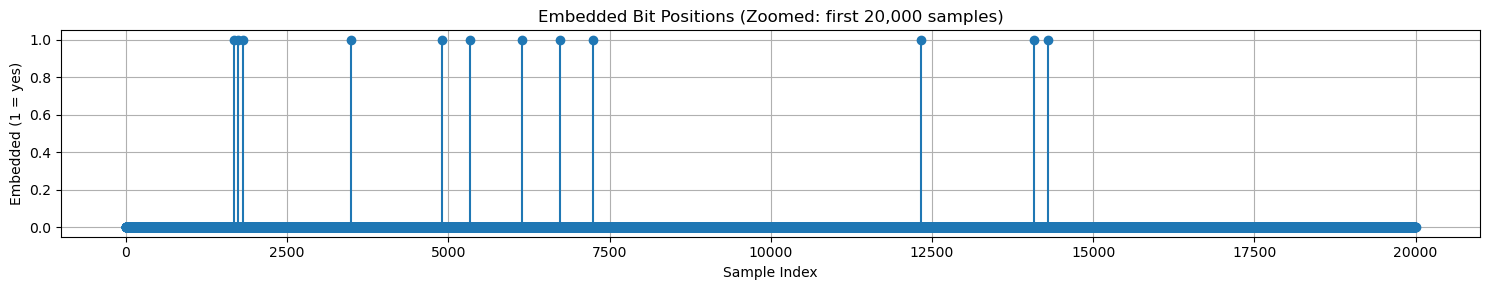

In [13]:
def visualize_embedding_positions(audio_file, message, seed=12345):
    message_bits = text_to_bits(message)
    total_bits = len(message_bits)
    num_positions = total_bits // 2

    sample_rate, audio_data = wav.read(audio_file)
    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1).astype(np.int16)
    total_samples = len(audio_data)

    random.seed(seed)
    positions = random.sample(range(total_samples), num_positions)

    mask = np.zeros(total_samples)
    mask[positions] = 1

    plt.figure(figsize=(15, 3))

    zoom_range = 20000
    zoom_mask = mask[:zoom_range]

    plt.stem(range(zoom_range), zoom_mask, basefmt=" ")
    plt.title("Embedded Bit Positions (Zoomed: first 20,000 samples)")
    plt.xlabel("Sample Index")
    plt.ylabel("Embedded (1 = yes)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


visualize_embedding_positions("output/Ex3_sound5_embedded.wav", secret_message, seed=12345)

#### How much did the audio change?

Only 180 of the 400,000 or so samples carry the message, and each changes by at most 3 steps. The difference is far below anything audible.

In [14]:
sr_o, original = wav.read("data/Ex3_sound5.wav")
sr_e, embedded = wav.read("output/Ex3_sound5_embedded.wav")
original = original.astype(np.int64)
embedded = embedded.astype(np.int64)
diff = embedded - original

signal_power = np.mean(original.astype(float) ** 2)
noise_power = np.mean(diff.astype(float) ** 2)

print(f"Samples in the file:          {len(original):,}")
print(f"Samples carrying the message: {len(secret_message) * 8 // 2}")
print(f"Samples whose value changed:  {np.count_nonzero(diff)} (the others already held the right bits)")
print(f"Largest change:               {np.abs(diff).max()} out of 32,768")
print(f"Signal-to-noise ratio:        {10 * np.log10(signal_power / noise_power):.1f} dB")

Samples in the file:          407,280
Samples carrying the message: 180
Samples whose value changed:  150 (the others already held the right bits)
Largest change:               3 out of 32,768
Signal-to-noise ratio:        103.4 dB
